In [ ]:
# ====================================================================================
# Copyright (c) 2026 [Haitham Sobhy]

# Permission is hereby granted, free of charge, to academic and non-profit
# researchers to inspect, run, and evaluate this software solely for non-profit
# academic research and peer-review evaluation purposes.

# MANDATORY CITATION REQUIREMENT:
# Any academic or non-profit usage, evaluation, or reference to this software
# MUST cite the following work:
# "Shetti-AI: Precise prediction of protein sequence mutational landscapes to
# accelerate functional assays (Under Revision)"

# RESTRICTIONS & PERMISSION REQUIREMENTS:

# 1. NO COMMERCIAL OR R&D USE: Any use, modification, integration, or testing by
#    or on behalf of commercial entities, for-profit corporations, or corporate
#    Research & Development (R&D) departments is STRICTLY PROHIBITED.

# 2. PRIOR PERMISSION REQUIRED: No part of this codebase, scripts, or algorithms
#    may be copied, modified, redistributed, or incorporated into other projects
#    without explicit prior written permission from the copyright holder.

# 3. COMMERCIAL LICENSING: For commercial inquiries, corporate R&D licensing,
#    or permission requests, please contact: [ hsobhy at live dot com ]

# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED.
# ====================================================================================

In [ ]:
# GAN and WGAN GenAI model

In [ ]:
# =============================================================
# # BIOLOGICAL MATRICES + BAYESIAN FUNCTIONS + MSE + PCA
# =============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# =============================================================
# AMINO-ACID DEFINITIONS
# =============================================================

AA_LIST = list("ARNDCEQGHILKMFPSTWYV")
AA_IDX = {aa: i for i, aa in enumerate(AA_LIST)}
N_AA = len(AA_LIST)


# =============================================================
# 18D PHYSICOCHEMICAL PROPERTY MATRIX
# =============================================================

AA_PROPS = {
'A': [0, 0.4, -0.42, -0.68, -0.21, -1, -1, -1, -0.33, 0.65, 0.12, -0.56, -0.75, -1, -1, -1, -1, -0.2],
'R': [1, -1, 0.75, 0.43, 0.32, -1, -1, 0, 0.85, 0.1, -0.35, -0.22, 0, 0, -1, 1, -1, 1],
'N': [0, -0.78, 0.9, -0.34, 0.15, -1, -1, 0, 0.85, -0.45, -0.35, 0.48, 0.3, 0, -1, -1, -1, 0.5],
'D': [-1, -0.78, 0.9, -0.37, 0.42, -1, -1, 0, 0.85, 0.12, -0.7, 0.52, 0.5, -1, -1, -1, 1, 0.5],
'C': [0, 0.51, -0.3, -0.41, -0.3, -1, 1, 1, -0.33, -0.3, 0.5, 0.18, -0.6, 0, -1, -1, 1, 0],
'E': [-1, -0.78, 0.9, -0.05, 0.28, -1, -1, 0, 0.85, 0.8, -0.8, -0.4, 0.4, -1, -1, -1, 1, 0.5],
'Q': [0, -0.78, 0.9, 0, 0.22, -1, -1, 0, 0.85, 0.4, -0.1, -0.22, 0.2, 0, -1, -1, -1, 0.5],
'G': [0, -0.18, -0.05, -1, 0.9, -1, -1, -1, -0.33, -0.8, -0.5, 1, 0.8, -1, -1, -1, -1, 0],
'H': [0, -0.71, 0.6, 0.19, -0.5, 1, -1, 0, 0.85, 0.3, -0.2, -0.22, -0.1, 0, 0, -1, 1, 0.5],
'I': [0, 1, -1, 0.34, 0.1, -1, -1, -1, -0.33, 0.1, 0.8, -0.8, -0.8, -1, -1, -1, -1, 0],
'L': [0, 0.84, -1, 0.34, -0.25, -1, -1, -1, -0.33, 0.7, 0.4, -0.56, -0.7, -1, -1, -1, -1, 0],
'K': [1, -0.87, 0.75, 0.36, 0.18, -1, -1, 0, 0.85, 0.4, -0.2, -0.1, 0, 1, -1, 1, -1, 1],
'M': [0, 0.42, -0.6, 0.28, -0.6, -1, 1, -1, -0.33, 0.4, 0.9, -0.5, -0.6, -1, -1, -1, 0, 0],
'F': [0, 0.62, -0.8, 0.58, -0.55, 1, -1, -1, -0.33, 0.2, 0.5, -0.5, -0.7, -1, -1, -1, -1, 0],
'P': [0, -0.36, -0.3, -0.35, -1, -1, -1, -1, -0.33, -1, -0.8, 1, 0.6, 0, -1, -1, -1, -0.2],
'S': [0, -0.2, 0.9, -0.66, 0.42, -1, -1, 0, 0.85, -0.3, -0.4, 0.7, 0.5, 1, 1, -1, -1, 0.5],
'T': [0, -0.16, 0.75, -0.31, 0.05, -1, -1, 0, 0.85, -0.2, 0.3, 0.4, 0.2, 1, 1, -1, -1, 0.5],
'W': [0, -0.09, -0.5, 1, -0.55, 1, -1, -1, 0.3, 0.3, 0.3, -0.22, -0.8, -1, -1, -1, -1, 0],
'Y': [0, -0.51, 0.3, 0.65, -0.05, 1, -1, 0, 0.3, -0.2, 0.5, 0.18, -0.1, 0, 1, -1, -1, 0],
'V': [0, 0.93, -1, 0.02, -0.1, -1, -1, -1, -0.33, 0.3, 0.9, -0.7, -0.8, -1, -1, -1, -1, 0]
}

PROP_MATRIX = np.array(
    [AA_PROPS[aa] for aa in AA_LIST],
    dtype=np.float32
)

PROP_DIM = PROP_MATRIX.shape[1]

print("Physicochemical dimensions:", PROP_DIM)


# =============================================================
# GENETIC / SNP RATIO MATRIX
# =============================================================

RATIO_DATA = {
'A': [0,3,2,3,2,3,2,3,2,2,2,2,1,2,3,3,3,2,2,3],
'R': [3,0,2,2,3,2,3,3,3,2,3,3,2,2,3,3,3,3,2,2],
'N': [2,2,0,3,2,2,2,2,3,3,2,3,2,2,2,3,3,1,3,2],
'D': [3,2,3,0,2,3,2,3,3,2,2,2,1,2,2,2,2,1,3,3],
'C': [2,3,2,2,0,1,2,3,2,2,2,1,1,3,2,3,2,3,3,2],
'E': [3,2,2,3,1,0,3,3,2,2,2,3,2,1,2,2,2,1,2,3],
'Q': [2,3,2,2,2,3,0,2,3,3,0,3,2,1,3,2,2,2,2,2],
'G': [3,3,2,3,3,3,2,0,2,2,2,2,1,2,2,3,2,3,2,3],
'H': [2,3,3,3,2,2,3,2,0,2,3,2,2,2,3,2,2,1,3,2],
'I': [2,2,3,2,2,2,2,2,2,0,3,3,3,3,2,3,3,2,2,3],
'L': [2,3,2,2,2,2,3,2,3,3,0,2,3,3,3,3,2,3,2,3],
'K': [2,3,3,2,1,3,3,2,2,3,2,0,3,1,2,2,3,1,2,2],
'M': [1,2,2,1,1,2,2,1,2,3,3,3,0,2,1,2,3,2,1,3],
'F': [2,2,2,2,3,1,1,2,2,3,3,1,2,0,2,3,2,2,3,3],
'P': [3,3,2,2,2,2,3,2,3,2,3,2,1,2,0,3,3,2,2,2],
'S': [3,3,3,2,3,2,2,3,2,3,3,2,2,3,3,0,3,3,3,2],
'T': [3,3,3,2,2,2,2,2,2,3,2,3,3,2,3,3,0,2,2,3],
'W': [2,3,1,1,3,1,2,3,1,2,3,1,2,2,2,3,2,0,1,2],
'Y': [2,2,3,3,3,2,2,2,3,2,2,2,1,3,2,3,2,1,0,2],
'V': [3,2,2,3,2,3,2,3,2,3,3,2,3,3,2,2,3,2,2,0]
}

RATIO_MATRIX = np.array(
    [RATIO_DATA[aa] for aa in AA_LIST],
    dtype=np.float32
)


# =============================================================
# BAYESIAN BIOLOGICAL DISTRIBUTION
# =============================================================

def bayesian_distribution(source_aa, beta_phys=4.0, exclude_identity=True):

    source_idx = AA_IDX[source_aa]

    ratio = RATIO_MATRIX[source_idx]

    prior = np.zeros(N_AA, dtype=np.float32)

    for j in range(N_AA):

        d = ratio[j]

        if d == 1:
            prior[j] = 3.0
        elif d == 2:
            prior[j] = 2.0
        elif d == 3:
            prior[j] = 1.0

    if exclude_identity:
        prior[source_idx] = 0.0

    prior = prior + 1e-8
    prior = prior / prior.sum()

    source_vector = PROP_MATRIX[source_idx]

    distances = np.linalg.norm(
        PROP_MATRIX - source_vector,
        axis=1
    )

    likelihood = np.exp(
        -beta_phys * distances
    )

    if exclude_identity:
        likelihood[source_idx] = 0.0

    likelihood = likelihood + 1e-8

    posterior = prior * likelihood
    posterior = posterior / posterior.sum()

    return posterior


# =============================================================
# MOTIF -> 18D REPRESENTATION
# =============================================================

def motif_to_18d(motif):

    return np.mean(
        np.array(
            [PROP_MATRIX[AA_IDX[aa]] for aa in motif]
        ),
        axis=0
    )


# =============================================================
# MSE BETWEEN REFERENCE AND GENERATED 18D FEATURES
# =============================================================

def calculate_motif_mse(ref_18d, generated_18d):

    mse_per_candidate = np.mean(
        (generated_18d - ref_18d) ** 2,
        axis=-1
    )

    return mse_per_candidate


# =============================================================
# PCA PLOT
# =============================================================

def plot_latent_space_pca(
    gan_18d,
    wgan_18d,
    ref_18d,
    bayesian_gan,
    bayesian_wgan
):

    all_features = np.vstack([
        gan_18d,
        wgan_18d,
        ref_18d
    ])

    pca = PCA(n_components=2)
    coords_2d = pca.fit_transform(all_features)

    n_gan = len(gan_18d)
    n_wgan = len(wgan_18d)

    gan_coords = coords_2d[:n_gan]
    wgan_coords = coords_2d[
        n_gan:n_gan + n_wgan
    ]

    ref_coord = coords_2d[-1]

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 6)
    )

    # ---------------------------------------------------------
    # GAN
    # ---------------------------------------------------------

    scatter1 = axes[0].scatter(
        gan_coords[:, 0],
        gan_coords[:, 1],
        c=bayesian_gan,
        cmap="viridis",
        alpha=0.75,
        s=45
    )

    axes[0].scatter(
        ref_coord[0],
        ref_coord[1],
        color="red",
        marker="*",
        s=250,
        label="Reference Motif"
    )

    axes[0].set_title(
        "GAN Candidate Distribution",
        fontweight="bold"
    )

    axes[0].set_xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Var)"
    )

    axes[0].set_ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Var)"
    )

    axes[0].legend()
    axes[0].grid(
        True,
        linestyle="--",
        alpha=0.4
    )

    plt.colorbar(
        scatter1,
        ax=axes[0],
        label="Log-Bayesian Score"
    )


    # ---------------------------------------------------------
    # WGAN-GP
    # ---------------------------------------------------------

    scatter2 = axes[1].scatter(
        wgan_coords[:, 0],
        wgan_coords[:, 1],
        c=bayesian_wgan,
        cmap="viridis",
        alpha=0.75,
        s=45
    )

    axes[1].scatter(
        ref_coord[0],
        ref_coord[1],
        color="red",
        marker="*",
        s=250,
        label="Reference Motif"
    )

    axes[1].set_title(
        "WGAN-GP Candidate Distribution",
        fontweight="bold"
    )

    axes[1].set_xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Var)"
    )

    axes[1].set_ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Var)"
    )

    axes[1].legend()
    axes[1].grid(
        True,
        linestyle="--",
        alpha=0.4
    )

    plt.colorbar(
        scatter2,
        ax=axes[1],
        label="Log-Bayesian Score"
    )

    plt.tight_layout()

    plt.savefig(
        "GAN_WGAN_PCA_18D.png",
        dpi=300
    )

    plt.show()


Physicochemical dimensions: 18


In [ ]:
# =============================================================
# # GAN / WGAN-GP MODELS AND TRAINING
# =============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", DEVICE)


# =============================================================
# CONVERT AMINO-ACID PROBABILITIES TO 18D PROPERTIES
# =============================================================

def probabilities_to_properties(probabilities):

    prop_matrix = torch.tensor(
        PROP_MATRIX,
        dtype=torch.float32,
        device=DEVICE
    )

    return torch.matmul(
        probabilities,
        prop_matrix
    )


# =============================================================
# CONDITIONAL GENERATOR
# =============================================================

class Generator(nn.Module):

    def __init__(
        self,
        prop_dim,
        latent_dim=32,
        hidden_dim=128
    ):

        super().__init__()

        self.latent_dim = latent_dim

        self.network = nn.Sequential(
            nn.Linear(prop_dim + latent_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, N_AA)
        )

    def forward(
        self,
        source_properties,
        noise
    ):

        x = torch.cat(
            [source_properties, noise],
            dim=-1
        )

        return self.network(x)


# =============================================================
# DISCRIMINATOR
# =============================================================

class Discriminator(nn.Module):

    def __init__(
        self,
        prop_dim,
        hidden_dim=128
    ):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(prop_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid()
        )

    def forward(self, properties):

        pooled = properties.mean(dim=1)

        return self.network(pooled)


# =============================================================
# WGAN-GP CRITIC
# =============================================================

class Critic(nn.Module):

    def __init__(
        self,
        prop_dim,
        hidden_dim=128
    ):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(prop_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, properties):

        pooled = properties.mean(dim=1)

        return self.network(pooled)


# =============================================================
# BAYESIAN CONSTRAINT
# =============================================================

def bayesian_constraint_loss(
    probabilities,
    motif,
    beta_phys=4.0
):

    losses = []

    for position, source_aa in enumerate(motif):

        bayes_target = torch.tensor(
            bayesian_distribution(
                source_aa,
                beta_phys=beta_phys
            ),
            dtype=torch.float32,
            device=DEVICE
        )

        predicted = probabilities[
            0,
            position
        ]

        predicted = predicted + 1e-8
        bayes_target = bayes_target + 1e-8

        kl = torch.sum(
            bayes_target *
            (
                torch.log(bayes_target)
                -
                torch.log(predicted)
            )
        )

        losses.append(kl)

    return torch.stack(losses).mean()


# =============================================================
# GRADIENT PENALTY
# =============================================================

def gradient_penalty(
    critic,
    real,
    fake
):

    batch_size = real.size(0)

    alpha = torch.rand(
        batch_size,
        1,
        1,
        device=DEVICE
    )

    interpolated = (
        alpha * real
        +
        (1 - alpha) * fake
    )

    interpolated.requires_grad_(True)

    critic_output = critic(
        interpolated
    )

    gradients = torch.autograd.grad(
        outputs=critic_output,
        inputs=interpolated,
        grad_outputs=torch.ones_like(
            critic_output
        ),
        create_graph=True,
        retain_graph=True
    )[0]

    gradients = gradients.reshape(
        batch_size,
        -1
    )

    gradient_norm = gradients.norm(
        2,
        dim=1
    )

    return (
        (gradient_norm - 1.0) ** 2
    ).mean()


# =============================================================
# TRAIN STANDARD GAN
# =============================================================

def train_gan(
    motif,
    epochs=2000,
    latent_dim=32,
    lr=1e-3,
    bayes_weight=2.0,
    beta_phys=4.0
):

    length = len(motif)

    G = Generator(
        PROP_DIM,
        latent_dim
    ).to(DEVICE)

    D = Discriminator(
        PROP_DIM
    ).to(DEVICE)

    g_optimizer = optim.Adam(
        G.parameters(),
        lr=lr,
        betas=(0.5, 0.999)
    )

    d_optimizer = optim.Adam(
        D.parameters(),
        lr=lr,
        betas=(0.5, 0.999)
    )

    real_indices = torch.tensor(
        [AA_IDX[aa] for aa in motif],
        dtype=torch.long,
        device=DEVICE
    )

    real_onehot = F.one_hot(
        real_indices,
        num_classes=N_AA
    ).float()

    real_onehot = real_onehot.unsqueeze(0)

    real_props = probabilities_to_properties(
        real_onehot
    )

    criterion = nn.BCELoss()

    g_losses = []
    d_losses = []
    bayes_losses = []
    mse_losses = []

    for epoch in range(epochs):

        # =====================================================
        # DISCRIMINATOR
        # =====================================================

        d_optimizer.zero_grad()

        real_prediction = D(
            real_props
        )

        real_labels = torch.ones(
            1,
            1,
            device=DEVICE
        )

        loss_real = criterion(
            real_prediction,
            real_labels
        )

        noise = torch.randn(
            1,
            length,
            latent_dim,
            device=DEVICE
        )

        fake_logits = G(
            real_props.detach(),
            noise
        )

        fake_probs = F.softmax(
            fake_logits,
            dim=-1
        )

        fake_props = probabilities_to_properties(
            fake_probs
        )

        fake_prediction = D(
            fake_props.detach()
        )

        fake_labels = torch.zeros(
            1,
            1,
            device=DEVICE
        )

        loss_fake = criterion(
            fake_prediction,
            fake_labels
        )

        d_loss = loss_real + loss_fake

        d_loss.backward()
        d_optimizer.step()

        # =====================================================
        # GENERATOR
        # =====================================================

        g_optimizer.zero_grad()

        noise = torch.randn(
            1,
            length,
            latent_dim,
            device=DEVICE
        )

        fake_logits = G(
            real_props,
            noise
        )

        fake_probs = F.softmax(
            fake_logits,
            dim=-1
        )

        fake_props = probabilities_to_properties(
            fake_probs
        )

        fake_prediction = D(
            fake_props
        )

        adversarial_loss = criterion(
            fake_prediction,
            real_labels
        )

        bayes_loss = bayesian_constraint_loss(
            fake_probs,
            motif,
            beta_phys
        )

        g_loss = (
            adversarial_loss
            +
            bayes_weight * bayes_loss
        )

        g_loss.backward()
        g_optimizer.step()

        # =====================================================
        # MSE
        # =====================================================

        mse = torch.mean(
            (fake_props - real_props) ** 2
        )

        g_losses.append(
            g_loss.item()
        )

        d_losses.append(
            d_loss.item()
        )

        bayes_losses.append(
            bayes_loss.item()
        )

        mse_losses.append(
            mse.item()
        )

        if (
            epoch == 0
            or (epoch + 1) % 250 == 0
        ):

            print(
                f"[GAN] Epoch {epoch + 1}/{epochs} | "
                f"D={d_loss.item():.4f} | "
                f"G={g_loss.item():.4f} | "
                f"Bayes={bayes_loss.item():.4f} | "
                f"MSE={mse.item():.6f}"
            )

    return G, {
        "g_losses": g_losses,
        "d_losses": d_losses,
        "bayes_losses": bayes_losses,
        "mse_losses": mse_losses
    }


# =============================================================
# TRAIN WGAN-GP
# =============================================================

def train_wgan(
    motif,
    epochs=2000,
    latent_dim=32,
    lr=1e-4,
    critic_steps=5,
    gp_weight=10.0,
    bayes_weight=2.0,
    beta_phys=4.0
):

    length = len(motif)

    G = Generator(
        PROP_DIM,
        latent_dim
    ).to(DEVICE)

    C = Critic(
        PROP_DIM
    ).to(DEVICE)

    g_optimizer = optim.Adam(
        G.parameters(),
        lr=lr,
        betas=(0.0, 0.9)
    )

    c_optimizer = optim.Adam(
        C.parameters(),
        lr=lr,
        betas=(0.0, 0.9)
    )

    real_indices = torch.tensor(
        [AA_IDX[aa] for aa in motif],
        dtype=torch.long,
        device=DEVICE
    )

    real_onehot = F.one_hot(
        real_indices,
        num_classes=N_AA
    ).float()

    real_onehot = real_onehot.unsqueeze(0)

    real_props = probabilities_to_properties(
        real_onehot
    )

    g_losses = []
    c_losses = []
    bayes_losses = []
    mse_losses = []

    for epoch in range(epochs):

        # =====================================================
        # CRITIC
        # =====================================================

        for _ in range(critic_steps):

            c_optimizer.zero_grad()

            noise = torch.randn(
                1,
                length,
                latent_dim,
                device=DEVICE
            )

            fake_logits = G(
                real_props.detach(),
                noise
            )

            fake_probs = F.softmax(
                fake_logits,
                dim=-1
            )

            fake_props = probabilities_to_properties(
                fake_probs
            )

            real_score = C(
                real_props
            )

            fake_score = C(
                fake_props.detach()
            )

            gp = gradient_penalty(
                C,
                real_props,
                fake_props.detach()
            )

            critic_loss = (
                -real_score.mean()
                +
                fake_score.mean()
                +
                gp_weight * gp
            )

            critic_loss.backward()
            c_optimizer.step()

        # =====================================================
        # GENERATOR
        # =====================================================

        g_optimizer.zero_grad()

        noise = torch.randn(
            1,
            length,
            latent_dim,
            device=DEVICE
        )

        fake_logits = G(
            real_props,
            noise
        )

        fake_probs = F.softmax(
            fake_logits,
            dim=-1
        )

        fake_props = probabilities_to_properties(
            fake_probs
        )

        fake_score = C(
            fake_props
        )

        adversarial_loss = (
            -fake_score.mean()
        )

        bayes_loss = bayesian_constraint_loss(
            fake_probs,
            motif,
            beta_phys
        )

        g_loss = (
            adversarial_loss
            +
            bayes_weight * bayes_loss
        )

        g_loss.backward()
        g_optimizer.step()

        # =====================================================
        # MSE
        # =====================================================

        mse = torch.mean(
            (fake_props - real_props) ** 2
        )

        g_losses.append(
            g_loss.item()
        )

        c_losses.append(
            critic_loss.item()
        )

        bayes_losses.append(
            bayes_loss.item()
        )

        mse_losses.append(
            mse.item()
        )

        if (
            epoch == 0
            or (epoch + 1) % 250 == 0
        ):

            print(
                f"[WGAN-GP] Epoch {epoch + 1}/{epochs} | "
                f"C={critic_loss.item():.4f} | "
                f"G={g_loss.item():.4f} | "
                f"Bayes={bayes_loss.item():.4f} | "
                f"MSE={mse.item():.6f}"
            )

    return G, {
        "g_losses": g_losses,
        "d_losses": c_losses,
        "bayes_losses": bayes_losses,
        "mse_losses": mse_losses
    }


Using device: cpu


In [ ]:
# =============================================================
# # SAMPLING + SCORING + PLOTS
# =============================================================

def sample_generator(
    G,
    motif,
    n_samples=50,
    temperature=1.0,
    latent_dim=32
):

    length = len(motif)

    source_indices = torch.tensor(
        [AA_IDX[aa] for aa in motif],
        dtype=torch.long,
        device=DEVICE
    )

    source_onehot = F.one_hot(
        source_indices,
        num_classes=N_AA
    ).float()

    source_onehot = source_onehot.unsqueeze(0)

    source_props = probabilities_to_properties(
        source_onehot
    )

    generated = []

    for _ in range(n_samples):

        noise = torch.randn(
            1,
            length,
            latent_dim,
            device=DEVICE
        )

        with torch.no_grad():

            logits = G(
                source_props,
                noise
            )

            scaled_logits = (
                logits / temperature
            )

            probabilities = F.softmax(
                scaled_logits,
                dim=-1
            )

        sequence = []

        for position in range(length):

            p = probabilities[
                0,
                position
            ].clone()

            original_idx = AA_IDX[
                motif[position]
            ]

            p[original_idx] = 0.0

            if p.sum() <= 0:
                p = torch.ones_like(p)

            p = p / p.sum()

            aa_index = torch.multinomial(
                p,
                1
            ).item()

            sequence.append(
                AA_LIST[aa_index]
            )

        generated.append(
            "".join(sequence)
        )

    return list(dict.fromkeys(generated))


# =============================================================
# BAYESIAN SCORE FOR COMPLETE MOTIF
# =============================================================

def score_generated_motif(
    original,
    candidate,
    beta_phys=4.0
):

    log_probability = 0.0

    for source_aa, target_aa in zip(
        original,
        candidate
    ):

        posterior = bayesian_distribution(
            source_aa,
            beta_phys
        )

        target_idx = AA_IDX[target_aa]

        p = posterior[target_idx]

        log_probability += np.log(
            p + 1e-12
        )

    return log_probability


# =============================================================
# CONVERT GENERATED MOTIFS TO 18D FEATURES
# =============================================================

def motifs_to_18d(motifs):

    return np.array([
        motif_to_18d(motif)
        for motif in motifs
    ])


# =============================================================
# LOSS CURVES
# =============================================================

def plot_gan_vs_wgan_loss(
    gan_history,
    wgan_history
):

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    # ---------------------------------------------------------
    # STANDARD GAN
    # ---------------------------------------------------------

    axes[0].plot(
        gan_history["g_losses"],
        label="Generator Loss",
        color="#2b5c8f"
    )

    axes[0].plot(
        gan_history["d_losses"],
        label="Discriminator Loss",
        color="#d95f02"
    )

    axes[0].set_title(
        "A) Standard GAN Loss",
        fontweight="bold"
    )

    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Loss")

    axes[0].legend()

    axes[0].grid(
        True,
        linestyle="--",
        alpha=0.5
    )


    # ---------------------------------------------------------
    # WGAN-GP
    # ---------------------------------------------------------

    axes[1].plot(
        wgan_history["g_losses"],
        label="Generator Loss",
        color="#2b5c8f"
    )

    axes[1].plot(
        wgan_history["d_losses"],
        label="Critic (D) Loss",
        color="#7570b3"
    )

    axes[1].set_title(
        "B) WGAN-GP Loss",
        fontweight="bold"
    )

    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Wasserstein Loss")

    axes[1].legend()

    axes[1].grid(
        True,
        linestyle="--",
        alpha=0.5
    )

    plt.tight_layout()

    plt.savefig(
        "GAN_vs_WGAN_Loss_Curves.png",
        dpi=300
    )

    plt.show()


# =============================================================
# MSE CURVES
# =============================================================

def plot_mse_curves(
    gan_history,
    wgan_history
):

    plt.figure(
        figsize=(9, 5)
    )

    plt.plot(
        gan_history["mse_losses"],
        label="GAN MSE",
        color="#d95f02",
        linewidth=1.5
    )

    plt.plot(
        wgan_history["mse_losses"],
        label="WGAN-GP MSE",
        color="#1b9e77",
        linewidth=1.5
    )

    plt.title(
        "18D Physicochemical MSE During Training",
        fontweight="bold"
    )

    plt.xlabel("Epochs")
    plt.ylabel("Mean Squared Error")

    plt.legend()

    plt.grid(
        True,
        linestyle="--",
        alpha=0.5
    )

    plt.tight_layout()

    plt.savefig(
        "GAN_WGAN_18D_MSE.png",
        dpi=300
    )

    plt.show()


# =============================================================
# BAYESIAN CONSTRAINT CURVES
# =============================================================

def plot_bayesian_curves(
    gan_history,
    wgan_history
):

    plt.figure(
        figsize=(9, 5)
    )

    plt.plot(
        gan_history["bayes_losses"],
        label="GAN Bayesian Constraint",
        color="#d95f02"
    )

    plt.plot(
        wgan_history["bayes_losses"],
        label="WGAN-GP Bayesian Constraint",
        color="#1b9e77"
    )

    plt.title(
        "Bayesian Biological Constraint During Training",
        fontweight="bold"
    )

    plt.xlabel("Epochs")
    plt.ylabel("KL Divergence")

    plt.legend()

    plt.grid(
        True,
        linestyle="--",
        alpha=0.5
    )

    plt.tight_layout()

    plt.savefig(
        "GAN_WGAN_Bayesian_Constraint.png",
        dpi=300
    )

    plt.show()



BIOLOGICAL MOTIF GENERATION: GAN vs WGAN-GP

Enter a single motif: MREL

Input motif: MREL
Epochs [default 2000]: 5000
Sampling temperature [default 1.0]: 1

TRAINING STANDARD GAN
[GAN] Epoch 1/5000 | D=1.3794 | G=5.2849 | Bayes=2.2984 | MSE=0.381135
[GAN] Epoch 250/5000 | D=0.6810 | G=5.6669 | Bayes=2.3197 | MSE=0.109326
[GAN] Epoch 500/5000 | D=0.6344 | G=8.6683 | Bayes=2.7578 | MSE=0.122718
[GAN] Epoch 750/5000 | D=0.5198 | G=8.0646 | Bayes=3.0716 | MSE=0.124348
[GAN] Epoch 1000/5000 | D=0.6238 | G=8.2373 | Bayes=3.5355 | MSE=0.148075
[GAN] Epoch 1250/5000 | D=0.8629 | G=7.8275 | Bayes=3.6288 | MSE=0.140906
[GAN] Epoch 1500/5000 | D=0.5624 | G=9.8250 | Bayes=3.7916 | MSE=0.148235
[GAN] Epoch 1750/5000 | D=0.5334 | G=8.7709 | Bayes=3.8397 | MSE=0.147000
[GAN] Epoch 2000/5000 | D=0.5713 | G=10.1697 | Bayes=3.9679 | MSE=0.152576
[GAN] Epoch 2250/5000 | D=0.7671 | G=8.7119 | Bayes=3.9066 | MSE=0.150600
[GAN] Epoch 2500/5000 | D=0.7283 | G=10.8881 | Bayes=3.9446 | MSE=0.153866
[GAN] Epo

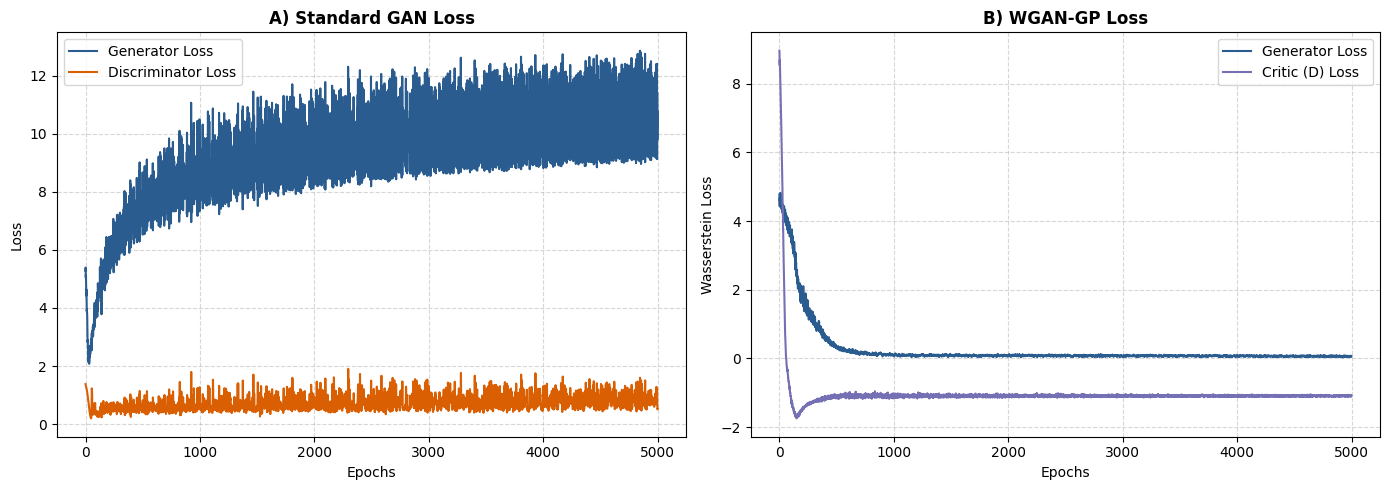

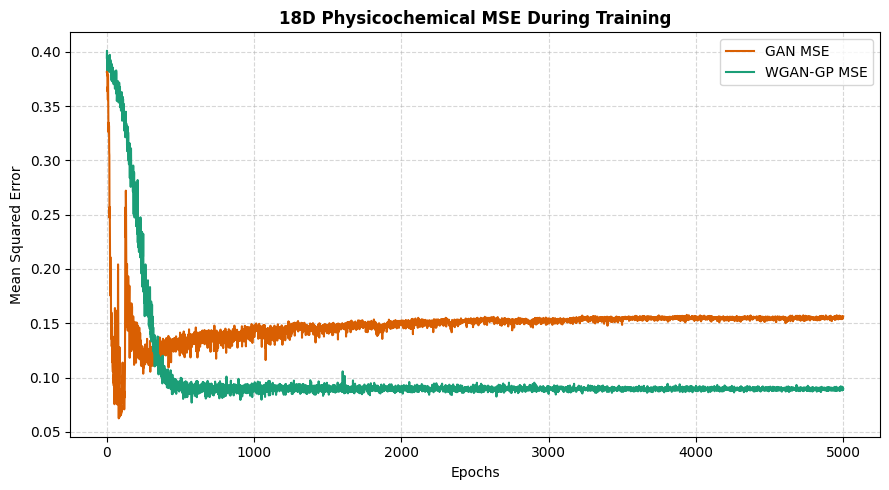

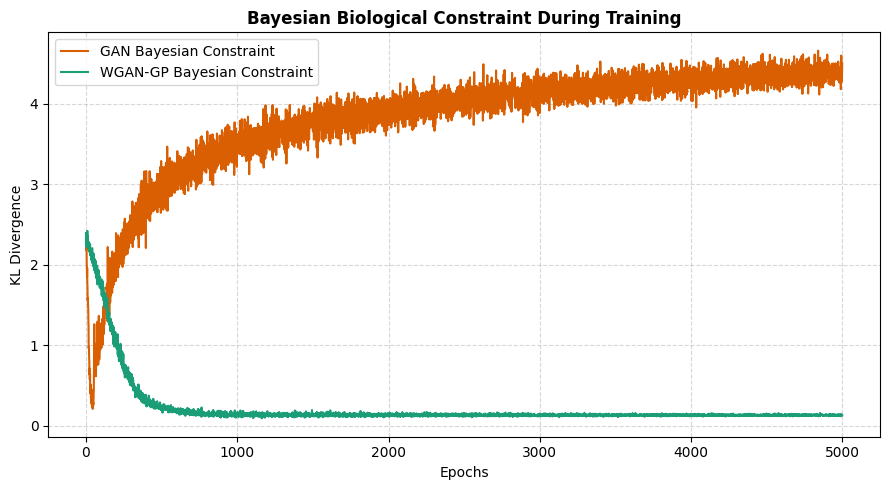

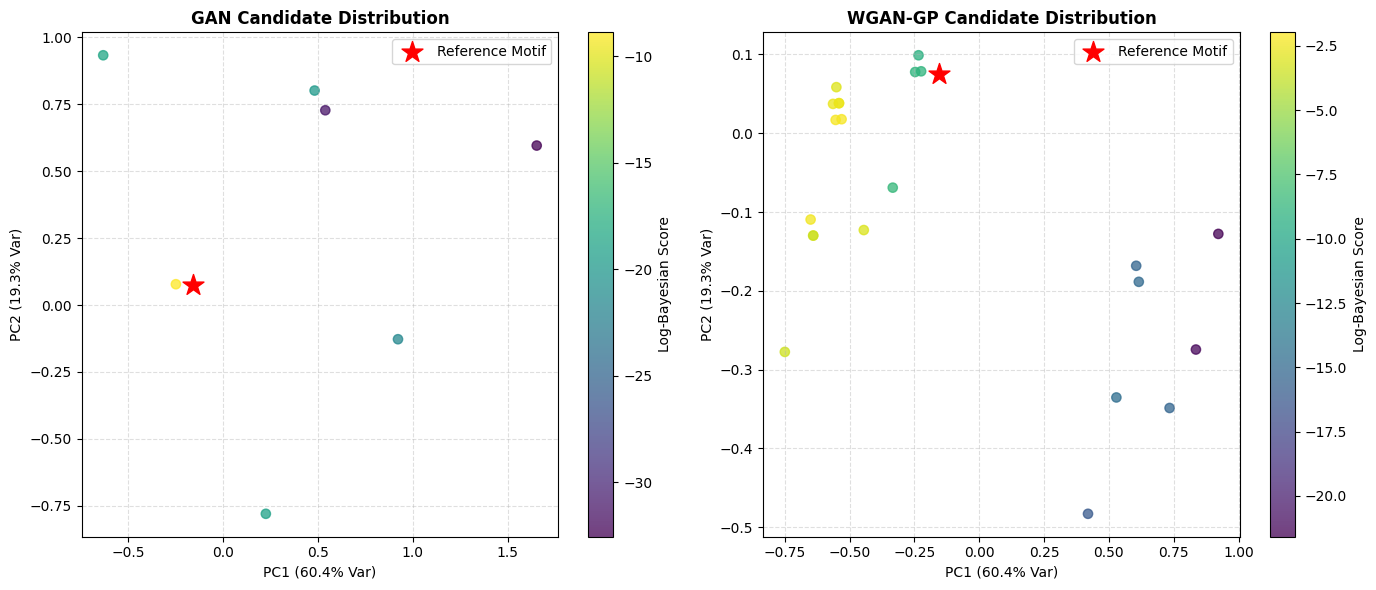

In [ ]:
# =============================================================
# # RUN GAN AND WGAN-GP TOGETHER
# =============================================================

print("\n" + "=" * 70)
print("BIOLOGICAL MOTIF GENERATION: GAN vs WGAN-GP")
print("=" * 70)

# =============================================================
# USER ENTERS ONE MOTIF
# =============================================================

motif = input(
    "\nEnter a single motif: "
).upper().strip()

if len(motif) == 0:
    raise ValueError(
        "Motif cannot be empty."
    )

invalid = [
    aa for aa in motif
    if aa not in AA_IDX
]

if invalid:
    raise ValueError(
        f"Invalid amino acid(s): {invalid}"
    )

print(
    f"\nInput motif: {motif}"
)


# =============================================================
# TRAINING PARAMETERS
# =============================================================

try:
    epochs = int(
        input(
            "Epochs [default 2000]: "
        )
    )
except ValueError:
    epochs = 2000


try:
    temperature = float(
        input(
            "Sampling temperature [default 1.0]: "
        )
    )
except ValueError:
    temperature = 1.0


# =============================================================
# TRAIN STANDARD GAN
# =============================================================

print("\n" + "=" * 70)
print("TRAINING STANDARD GAN")
print("=" * 70)

G_GAN, gan_history = train_gan(
    motif,
    epochs=epochs
)


# =============================================================
# TRAIN WGAN-GP
# =============================================================

print("\n" + "=" * 70)
print("TRAINING WGAN-GP")
print("=" * 70)

G_WGAN, wgan_history = train_wgan(
    motif,
    epochs=epochs
)


# =============================================================
# GENERATE GAN CANDIDATES
# =============================================================

gan_candidates = sample_generator(
    G_GAN,
    motif,
    n_samples=50,
    temperature=temperature
)


# =============================================================
# GENERATE WGAN-GP CANDIDATES
# =============================================================

wgan_candidates = sample_generator(
    G_WGAN,
    motif,
    n_samples=50,
    temperature=temperature
)


# =============================================================
# SCORE GAN CANDIDATES
# =============================================================

gan_scores = np.array([
    score_generated_motif(
        motif,
        candidate
    )
    for candidate in gan_candidates
])


# =============================================================
# SCORE WGAN-GP CANDIDATES
# =============================================================

wgan_scores = np.array([
    score_generated_motif(
        motif,
        candidate
    )
    for candidate in wgan_candidates
])


# =============================================================
# 18D REPRESENTATIONS
# =============================================================

ref_18d = motif_to_18d(
    motif
)

gan_18d = motifs_to_18d(
    gan_candidates
)

wgan_18d = motifs_to_18d(
    wgan_candidates
)


# =============================================================
# MSE
# =============================================================

gan_mse = calculate_motif_mse(
    ref_18d,
    gan_18d
)

wgan_mse = calculate_motif_mse(
    ref_18d,
    wgan_18d
)


# =============================================================
# SORT RESULTS
# =============================================================

gan_order = np.argsort(
    gan_scores
)[::-1]

wgan_order = np.argsort(
    wgan_scores
)[::-1]


# =============================================================
# DISPLAY GAN RESULTS
# =============================================================

print("\n" + "=" * 70)
print("GAN GENERATED CANDIDATES")
print("=" * 70)

for rank, index in enumerate(
    gan_order[:25],
    start=1
):

    print(
        f"{rank:02d}. "
        f"{gan_candidates[index]:<20} "
        f"log-Bayes={gan_scores[index]:.4f} "
        f"MSE={gan_mse[index]:.6f}"
    )


# =============================================================
# DISPLAY WGAN-GP RESULTS
# =============================================================

print("\n" + "=" * 70)
print("WGAN-GP GENERATED CANDIDATES")
print("=" * 70)

for rank, index in enumerate(
    wgan_order[:25],
    start=1
):

    print(
        f"{rank:02d}. "
        f"{wgan_candidates[index]:<20} "
        f"log-Bayes={wgan_scores[index]:.4f} "
        f"MSE={wgan_mse[index]:.6f}"
    )


# =============================================================
# SUMMARY
# =============================================================

print("\n" + "=" * 70)
print("MODEL SUMMARY")
print("=" * 70)

print(
    f"GAN     | "
    f"Mean MSE = {np.mean(gan_mse):.6f} | "
    f"Best Bayesian = {np.max(gan_scores):.4f}"
)

print(
    f"WGAN-GP | "
    f"Mean MSE = {np.mean(wgan_mse):.6f} | "
    f"Best Bayesian = {np.max(wgan_scores):.4f}"
)


# =============================================================
# DRAW LOSS CURVES
# =============================================================

plot_gan_vs_wgan_loss(
    gan_history,
    wgan_history
)


# =============================================================
# DRAW MSE CURVES
# =============================================================

plot_mse_curves(
    gan_history,
    wgan_history
)


# =============================================================
# DRAW BAYESIAN CONSTRAINT CURVES
# =============================================================

plot_bayesian_curves(
    gan_history,
    wgan_history
)


# =============================================================
# DRAW 18D PCA DISTRIBUTION
# =============================================================

plot_latent_space_pca(
    gan_18d,
    wgan_18d,
    ref_18d,
    gan_scores,
    wgan_scores
)
